In [299]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import os
import boost_histogram as bh
from particle_utils import get_charge_from_pdgc, get_name_from_pdgc
from tqdm import tqdm
import awkward as ak
from collections.abc import Sequence
import matplotlib.ticker as plticker



In [300]:
lumi_sf = 3000/40800 # Rescale to 3 fb^-1
density_sf = 0.1786/1.2929
he_sf = density_sf * lumi_sf
air_sf = lumi_sf

print(f"Density ratio: {density_sf:.2f}")

Density ratio: 0.14


In [301]:
data = uproot.open("../../GeantOutput/AirDv40800.root:Hits")
events = data.arrays(data.keys())

In [302]:
class NuDataSet(Sequence):
    
    def __init__(self, name, events, hits_mask=None, latex_name=None):
        self.name = name
        self.events = events
        self.hits_mask = hits_mask
        self.latex_name = latex_name if latex_name is not None else name
    
    def __getitem__(self, i):
        return self.events[i]
    
    def __len__(self):
        return len(self.events)

In [303]:
def vertex_cut(events, x1=-1500, x2=1500, y1=-500, y2=500, z1=0, z2=10000):
    return events[(x1 < events['vertex_x']) &  
                  (events['vertex_x'] < x2) & 
                  (y1 < events['vertex_y']) &
                  (events['vertex_y'] < y2) &
                  (z1 < events['vertex_z']) &
                  (events['vertex_z']< z2)]

In [304]:
nc_data = NuDataSet("Neutral Current", vertex_cut(events[events['isCC'] == False]), latex_name="NC")
cc_el_data = NuDataSet("Charged Current Electron", vertex_cut(events[(abs(events['nu_pdgc']) == 12) & (events['isCC'] == True)]), r"CC $\nu_e$")
cc_mu_data = NuDataSet("Charged Current Muon", vertex_cut(events[(abs(events['nu_pdgc']) == 14) & (events['isCC'] == True)]), r"CC $\nu_\mu$")
cc_tau_data = NuDataSet("Charged Current Tau", vertex_cut(events[(abs(events['nu_pdgc']) == 16) & (events['isCC'] == True)]), r"CC $\nu_\tau$")

In [305]:
print("------ Air ------")
print(f"NC = {len(nc_data) * air_sf:.1f}")
print(f"CC el = {len(cc_el_data) * air_sf:.1f}")
print(f"CC mu = {len(cc_mu_data) * air_sf:.1f}")
print(f"CC tau = {len(cc_tau_data) * air_sf:.1f}")
print(f"Total = {(len(nc_data)+len(cc_el_data)+len(cc_mu_data)+len(cc_tau_data))*air_sf:.1f}")

------ Air ------
NC = 171.6
CC el = 88.2
CC mu = 427.3
CC tau = 4.1
Total = 691.2


In [306]:
print("------ Helium ------")
print(f"NC = {len(nc_data) * he_sf:.1f}")
print(f"CC el = {len(cc_el_data) * he_sf:.1f}")
print(f"CC mu = {len(cc_mu_data) * he_sf:.1f}")
print(f"CC tau = {len(cc_tau_data) * he_sf:.1f}")
print(f"Total = {(len(nc_data)+len(cc_el_data)+len(cc_mu_data)+len(cc_tau_data))*he_sf:.1f}")

------ Helium ------
NC = 23.7
CC el = 12.2
CC mu = 59.0
CC tau = 0.6
Total = 95.5


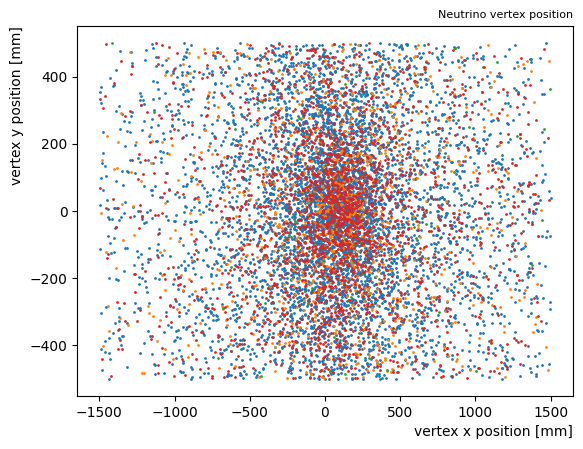

In [307]:
fig, ax = plt.subplots()
ax.scatter(cc_mu_data['vertex_x'], cc_mu_data['vertex_y'], s=1);
ax.scatter(cc_el_data['vertex_x'], cc_el_data['vertex_y'], s=1);
ax.scatter(cc_tau_data['vertex_x'], cc_tau_data['vertex_y'], s=1);
ax.scatter(nc_data['vertex_x'], nc_data['vertex_y'], s=1);
ax.set_xlabel("vertex x position [mm]", loc='right')
ax.set_ylabel("vertex y position [mm]", loc='top')
ax.set_title("Neutrino vertex position", loc='right', fontsize=8)
plt.savefig("HeDv-vertex-scatter.pdf")

In [308]:
def compute_masks(events, energy_threshold=None):
    masks = []
    
    #* Require hits which are within nominal 3 x 1 m tracking window, are charged 
    #* and are in the final tracking layer (this approximates requirement for hits in all layers)
    
    for event in events:
        mask = []
        
        # vx, vy, vz = event['vertex_x'], event['vertex_y'], event['vertex_z']
        # if -1500 < vx < 1500 and -500 < vy < 500 and 0 < vz < 10000:
        for x, y, layer, pdgc, energy in zip(event['x'], event['y'], event['layer'], event['pdgc'], event['E']):
            if -1500 < x < 1500 and -500 < y < 500 and get_charge_from_pdgc(pdgc) != 0 and layer == 5:
                # print(True)
                # print(get_charge_from_pdgc(pdgc))
                if energy_threshold is not None and energy < energy_threshold:
                    mask.append(False)    
                else:
                    mask.append(True)
            else:
                mask.append(False)
                # print(False)
        masks.append(mask)
    
    return ak.Array(masks)    

In [309]:
nc_data.hits_mask = compute_masks(nc_data.events)
cc_el_data.hits_mask = compute_masks(cc_el_data.events) 
cc_mu_data.hits_mask = compute_masks(cc_mu_data.events) 
cc_tau_data.hits_mask = compute_masks(cc_tau_data.events) 

In [332]:
def fill_hits_histogram(histogram, dataset, variable, func=None, cut=None, fill_zero=False):
    c = 0
    for i, event in enumerate(dataset):
        try:
            if cut is not None:
                event = cut(event)
            if func is not None:
                val = func(event[variable][dataset.hits_mask[i]])
                if val == 0 and not fill_zero: continue
                histogram.fill(val)
            else:
                val = event[variable][dataset.hits_mask[i]]
                # if val == 0 and not fill_zero: continue
                print(get_name_from_pdgc(val), get_charge_from_pdgc(val))
                # print(val)
                histogram.fill(val)
            c = c + 1
        except Exception as e:
            pass
    
    
    print(dataset.name, c)
    return histogram

In [311]:
nc_energy_hist     = bh.Histogram(bh.axis.Regular(10, 0, 750))
cc_el_energy_hist  = bh.Histogram(bh.axis.Regular(10, 0, 750))
cc_mu_energy_hist  = bh.Histogram(bh.axis.Regular(10, 0, 750))
cc_tau_energy_hist = bh.Histogram(bh.axis.Regular(10, 0, 750))

nc_energy_hist = fill_hits_histogram(nc_energy_hist, nc_data, "E", func=np.max)
cc_el_energy_hist = fill_hits_histogram(cc_el_energy_hist, cc_el_data, "E", func=np.max)
cc_mu_energy_hist = fill_hits_histogram(cc_mu_energy_hist, cc_mu_data, "E", func=np.max)
cc_tau_energy_hist = fill_hits_histogram(cc_tau_energy_hist, cc_tau_data, "E", func=np.max)

Neutral Current 2334
Charged Current Electron 1199
Charged Current Muon 5811
Charged Current Tau 56


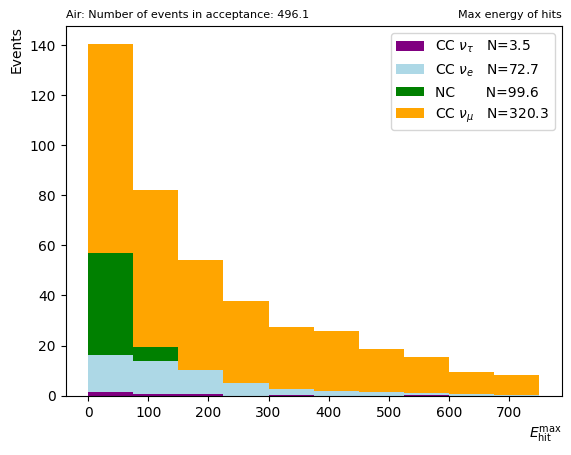

In [312]:
bin_edges = nc_energy_hist.axes[0].edges
bin_centers = nc_energy_hist.axes[0].centers
bin_width = bin_edges[1] - bin_edges[0]

stacked_counts = np.stack([cc_tau_energy_hist.view(),  cc_el_energy_hist.view(), nc_energy_hist.view(), cc_mu_energy_hist.view()])*air_sf
total = (sum(nc_energy_hist.view()) + sum(cc_mu_energy_hist.view()) + sum(cc_el_energy_hist.view()) + sum(cc_tau_energy_hist.view())) * air_sf


fig, ax = plt.subplots()
ax.bar(bin_centers, stacked_counts[0], width=bin_width, label=r'CC $\nu_\tau$' + f"   N={sum(cc_tau_energy_hist.view())*air_sf:.1f}", color='purple')
ax.bar(bin_centers, stacked_counts[1], width=bin_width, bottom=stacked_counts[0], label=r'CC $\nu_e$'+ f"   N={sum(cc_el_energy_hist.view())*air_sf:.1f}", color='lightblue')
ax.bar(bin_centers, stacked_counts[2], width=bin_width, bottom=stacked_counts[1], label='NC'+ f"       N={sum(nc_energy_hist.view())*air_sf:.1f}", color='green')
ax.bar(bin_centers, stacked_counts[3], width=bin_width, bottom=stacked_counts[2], label=r'CC $\nu_\mu$'+ f"   N={sum(cc_mu_energy_hist.view())*air_sf:.1f}", color='orange')

ax.set_xlabel(r'$E_\text{hit}^\text{max}$', loc='right')
# ax.set_ylabel(f'Events / {bin_width:.2f} GeV', loc='top')
ax.set_ylabel(f'Events', loc='top')
ax.set_title('Max energy of hits', loc='right', fontsize=8)
ax.set_title(f'Air: Number of events in acceptance: {total:.1f}', loc='left', fontsize=8)
ax.legend()
plt.show()

In [313]:
# bin_edges = nc_energy_hist.axes[0].edges
# bin_centers = nc_energy_hist.axes[0].centers
# bin_width = bin_edges[1] - bin_edges[0]

# stacked_counts = np.stack([cc_tau_energy_hist.view(),  cc_el_energy_hist.view(), nc_energy_hist.view(), cc_mu_energy_hist.view()])*he_sf
# total = (sum(nc_energy_hist.view()) + sum(cc_mu_energy_hist.view()) + sum(cc_el_energy_hist.view()) + sum(cc_tau_energy_hist.view())) * he_sf


# fig, ax = plt.subplots()
# ax.bar(bin_centers, stacked_counts[0], width=bin_width, label=r'CC $\nu_\tau$' + f"   N={sum(cc_tau_energy_hist.view())*he_sf:.1f}", color='purple')
# ax.bar(bin_centers, stacked_counts[1], width=bin_width, bottom=stacked_counts[0], label=r'CC $\nu_e$'+ f"   N={sum(cc_el_energy_hist.view())*he_sf:.1f}", color='lightblue')
# ax.bar(bin_centers, stacked_counts[2], width=bin_width, bottom=stacked_counts[1], label='NC'+ f"       N={sum(nc_energy_hist.view())*he_sf:.1f}", color='green')
# ax.bar(bin_centers, stacked_counts[3], width=bin_width, bottom=stacked_counts[2], label=r'CC $\nu_\mu$'+ f"   N={sum(cc_mu_energy_hist.view())*he_sf:.1f}", color='orange')

# ax.set_xlabel(r'$E_\text{hit}^\text{max}$', loc='right')
# # ax.set_ylabel(f'Events / {bin_width:.2f} GeV', loc='top')
# ax.set_ylabel(f'Events', loc='top')
# ax.set_title('Max energy of hits', loc='right', fontsize=8)
# ax.set_title(f'Helium: Number of events in acceptance: {total:.1f}', loc='left', fontsize=8)
# ax.legend()
# plt.show()

In [314]:
nc_nhits_hist     = bh.Histogram(bh.axis.Regular(29, 0, 30, overflow=True))
cc_el_nhits_hist  = bh.Histogram(bh.axis.Regular(29, 0, 30, overflow=True))
cc_mu_nhits_hist  = bh.Histogram(bh.axis.Regular(29, 0, 30, overflow=True))
cc_tau_nhits_hist = bh.Histogram(bh.axis.Regular(29, 0, 30, overflow=True))

nc_nhits_hist = fill_hits_histogram(nc_nhits_hist, nc_data, "x", len, fill_zero=False)
cc_el_nhits_hist = fill_hits_histogram(cc_el_nhits_hist, cc_el_data, "x", len, fill_zero=False)
cc_mu_nhits_hist = fill_hits_histogram(cc_mu_nhits_hist, cc_mu_data, "x", len, fill_zero=False)
cc_tau_nhits_hist = fill_hits_histogram(cc_tau_nhits_hist, cc_tau_data, "x", len, fill_zero=False)

Neutral Current 1366
Charged Current Electron 1101
Charged Current Muon 5061
Charged Current Tau 49


In [315]:
nc_energy_hist     = bh.Histogram(bh.axis.Regular(20, 0, 2000))
cc_el_energy_hist  = bh.Histogram(bh.axis.Regular(20, 0, 2000))
cc_mu_energy_hist  = bh.Histogram(bh.axis.Regular(20, 0, 2000))
cc_tau_energy_hist = bh.Histogram(bh.axis.Regular(20, 0, 2000))

nc_energy_hist = fill_hits_histogram(nc_energy_hist, nc_data, "E", func=max)
cc_el_energy_hist = fill_hits_histogram(cc_el_energy_hist, cc_el_data, "E", func=max)
cc_mu_energy_hist = fill_hits_histogram(cc_mu_energy_hist, cc_mu_data, "E", func=max)
cc_tau_energy_hist = fill_hits_histogram(cc_tau_energy_hist, cc_tau_data, "E", func=max)

Neutral Current 1366
Charged Current Electron 1101
Charged Current Muon 5061
Charged Current Tau 49


In [316]:
all_nc_energy_hist     = bh.Histogram(bh.axis.Regular(20, 0, 2000))
all_cc_el_energy_hist  = bh.Histogram(bh.axis.Regular(20, 0, 2000))
all_cc_mu_energy_hist  = bh.Histogram(bh.axis.Regular(20, 0, 2000))
all_cc_tau_energy_hist = bh.Histogram(bh.axis.Regular(20, 0, 2000))

all_nc_energy_hist = fill_hits_histogram(all_nc_energy_hist, nc_data, "E")
all_cc_el_energy_hist = fill_hits_histogram(all_cc_el_energy_hist, cc_el_data, "E")
all_cc_mu_energy_hist = fill_hits_histogram(all_cc_mu_energy_hist, cc_mu_data, "E")
all_cc_tau_energy_hist = fill_hits_histogram(all_cc_tau_energy_hist, cc_tau_data, "E")

Neutral Current 2334
Charged Current Electron 1199
Charged Current Muon 5811
Charged Current Tau 56


In [317]:
def plot_stacked_hist(histograms, names, colours, scale_factor=1, xlabel="variable", ylabel='events', title_right="", title_left="", xrange=None):
    
    total_hist_sizes = [sum(h.view(flow=True)) for h in histograms]
    combined_args = list(zip(total_hist_sizes, histograms, names, colours))
    sorted_combined_args = sorted(combined_args)
    total_hist_size, histograms, names, colours = zip(*sorted_combined_args)
    
    bin_edges = histograms[0].axes[0].edges
    bin_centers = histograms[0].axes[0].centers
    bin_width = bin_edges[1] - bin_edges[0]

    stacked_counts = np.stack([h.view(flow=True) for h in histograms])*scale_factor
    total = sum(total_hist_sizes) * scale_factor

    print(f"Total number of histogram entries: {total:.1f}")
    fig, ax = plt.subplots()
    for i, (histogram, name, colour) in enumerate(zip(histograms, names, colours)):
        values = stacked_counts[i]
        # values[1] += values[0]
        values[-2] += values[-1]
        if i == 0:
            ax.bar(bin_centers, values[1:-1], width=bin_width, label=name+ f"   N={sum(histogram.view())*scale_factor:.1f}", color=colour)
        else:
            bottom_values = stacked_counts[i-1]
            # bottom_values[1] += bottom_values[0]
            # bottom_values[-2] += bottom_values[-1]
            ax.bar(bin_centers, values[1:-1], width=bin_width, bottom=bottom_values[1:-1], label=name+ f"   N={sum(histogram.view())*scale_factor:.1f}", color=colour)
            

    ax.set_xlabel(xlabel, loc='right')
    # ax.set_ylabel(f'Events / {bin_width:.2f} GeV', loc='top')
    # ax.set_xticks(np.linspace(min(bin_edges), max(bin_edges)+1, len(bin_edges)))
    # loc = plticker.MultipleLocator(base=1.0) # this locator puts ticks at regular intervals
    # ax.xaxis.set_major_locator(loc)
    ax.set_ylabel(ylabel, loc='top')
    ax.set_title(title_right, loc='right', fontsize=8)
    ax.set_title(f'{title_left}', loc='left', fontsize=8)
    if xrange is not None:
        ax.set_xlim(xrange)
    ax.legend()
    plt.show()

Neutral Current 2334
Charged Current Electron 1199
Charged Current Muon 5811
Charged Current Tau 56
Total number of histogram entries: 1704.9


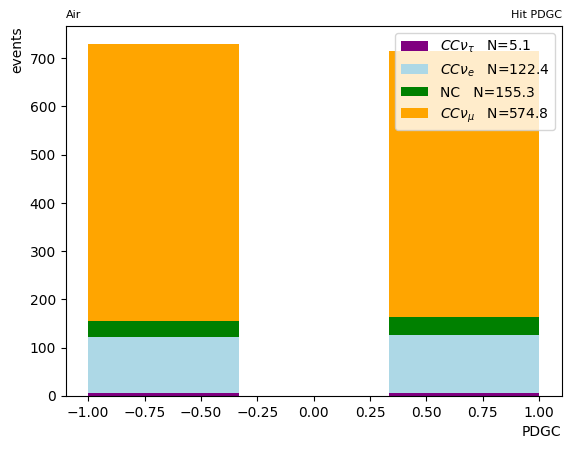

In [318]:
nc_energy_hist     = bh.Histogram(bh.axis.Regular(3, -1, 1))
cc_el_energy_hist  = bh.Histogram(bh.axis.Regular(3, -1, 1))
cc_mu_energy_hist  = bh.Histogram(bh.axis.Regular(3, -1, 1))
cc_tau_energy_hist = bh.Histogram(bh.axis.Regular(3, -1, 1))

nc_energy_hist = fill_hits_histogram(nc_energy_hist, nc_data, "charge")
cc_el_energy_hist = fill_hits_histogram(cc_el_energy_hist, cc_el_data, "charge")
cc_mu_energy_hist = fill_hits_histogram(cc_mu_energy_hist, cc_mu_data, "charge")
cc_tau_energy_hist = fill_hits_histogram(cc_tau_energy_hist, cc_tau_data, "charge")

plot_stacked_hist([nc_energy_hist, cc_el_energy_hist, cc_mu_energy_hist, cc_tau_energy_hist],
                  ["NC", r"$CC \nu_e$", r"$CC \nu_\mu$", r"$CC \nu_\tau$"],
                  ["green", "lightblue", "orange", "purple"],
                  scale_factor=air_sf, xlabel=r"PDGC", 
                    title_left="Air", title_right="Hit PDGC"
                  )

In [319]:
print("------ Air ------")
print(f"NC = {len(nc_data) * air_sf:.1f}")
print(f"CC el = {len(cc_el_data) * air_sf:.1f}")
print(f"CC mu = {len(cc_mu_data) * air_sf:.1f}")
print(f"CC tau = {len(cc_tau_data) * air_sf:.1f}")
print(f"Total = {(len(nc_data)+len(cc_el_data)+len(cc_mu_data)+len(cc_tau_data))*air_sf:.1f}")

------ Air ------
NC = 171.6
CC el = 88.2
CC mu = 427.3
CC tau = 4.1
Total = 691.2


Total number of histogram entries: 557.1


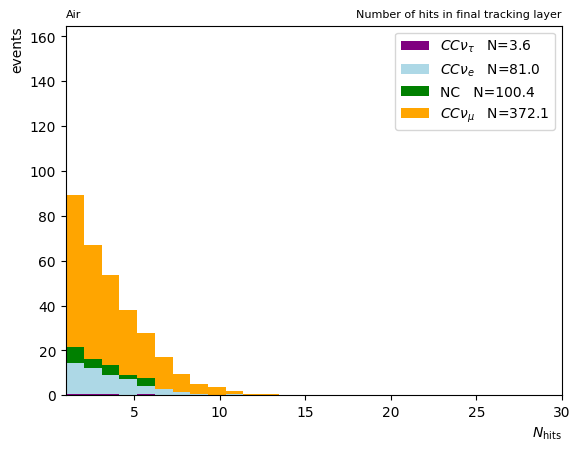

In [320]:
plot_stacked_hist([nc_nhits_hist, cc_el_nhits_hist, cc_mu_nhits_hist, cc_tau_nhits_hist],
                  ["NC", r"$CC \nu_e$", r"$CC \nu_\mu$", r"$CC \nu_\tau$"],
                  ["green", "lightblue", "orange", "purple"],
                  scale_factor=air_sf, xlabel=r"$N_\text{hits}$", 
                  title_left="Air", title_right="Number of hits in final tracking layer",
                  xrange=[1, 30]
                  )

Total number of histogram entries: 1704.9


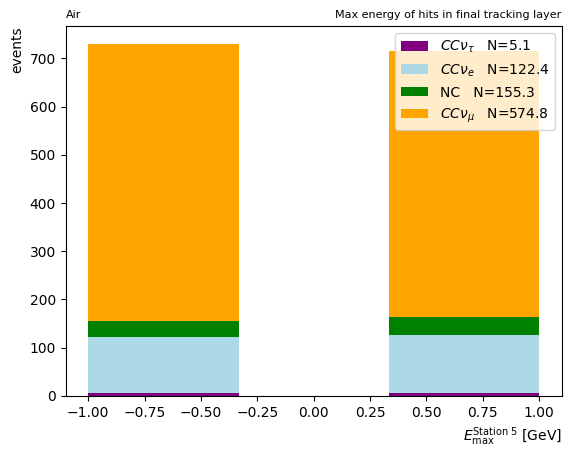

In [321]:
plot_stacked_hist([nc_energy_hist, cc_el_energy_hist, cc_mu_energy_hist, cc_tau_energy_hist],
                  ["NC", r"$CC \nu_e$", r"$CC \nu_\mu$", r"$CC \nu_\tau$"],
                  ["green", "lightblue", "orange", "purple"],
                  scale_factor=air_sf, xlabel=r"$E_\text{max}^\text{Station 5}$ [GeV]", 
                  title_left="Air", title_right="Max energy of hits in final tracking layer",
                  )

Total number of histogram entries: 1704.9


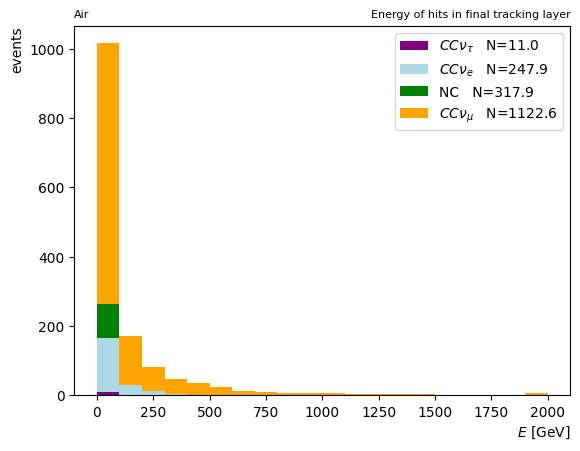

In [322]:
plot_stacked_hist([all_nc_energy_hist, all_cc_el_energy_hist, all_cc_mu_energy_hist, all_cc_tau_energy_hist],
                  ["NC", r"$CC \nu_e$", r"$CC \nu_\mu$", r"$CC \nu_\tau$"],
                  ["green", "lightblue", "orange", "purple"],
                  scale_factor=air_sf, xlabel=r"$E$ [GeV]", 
                  title_left="Air", title_right="Energy of hits in final tracking layer",
                  )

Neutral Current 1226
Charged Current Electron 1077
Charged Current Muon 4951
Charged Current Tau 48
Total number of histogram entries: 536.9


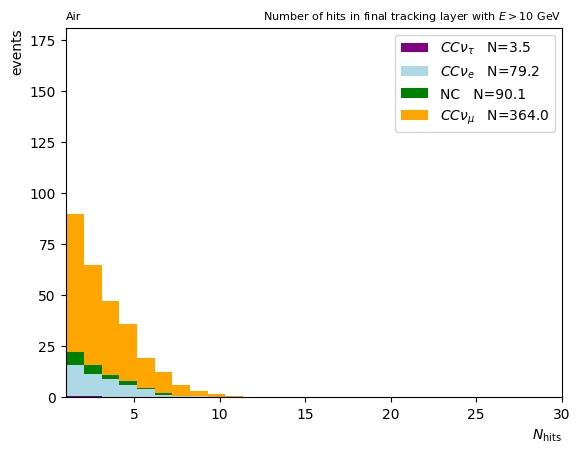

In [323]:
nc_data.hits_mask = compute_masks(nc_data.events, energy_threshold=10)
cc_el_data.hits_mask = compute_masks(cc_el_data.events, energy_threshold=10)
cc_mu_data.hits_mask = compute_masks(cc_mu_data.events, energy_threshold=10)
cc_tau_data.hits_mask = compute_masks(cc_tau_data.events, energy_threshold=10)


nc_nhits_hist     = bh.Histogram(bh.axis.Regular(29, 0, 30, overflow=True))
cc_el_nhits_hist  = bh.Histogram(bh.axis.Regular(29, 0, 30, overflow=True))
cc_mu_nhits_hist  = bh.Histogram(bh.axis.Regular(29, 0, 30, overflow=True))
cc_tau_nhits_hist = bh.Histogram(bh.axis.Regular(29, 0, 30, overflow=True))

nc_nhits_hist = fill_hits_histogram(nc_nhits_hist, nc_data, "x", len, fill_zero=False)
cc_el_nhits_hist = fill_hits_histogram(cc_el_nhits_hist, cc_el_data, "x", len, fill_zero=False)
cc_mu_nhits_hist = fill_hits_histogram(cc_mu_nhits_hist, cc_mu_data, "x", len, fill_zero=False)
cc_tau_nhits_hist = fill_hits_histogram(cc_tau_nhits_hist, cc_tau_data, "x", len, fill_zero=False)

plot_stacked_hist([nc_nhits_hist, cc_el_nhits_hist, cc_mu_nhits_hist, cc_tau_nhits_hist],
                  ["NC", r"$CC \nu_e$", r"$CC \nu_\mu$", r"$CC \nu_\tau$"],
                  ["green", "lightblue", "orange", "purple"],
                  scale_factor=air_sf, xlabel=r"$N_\text{hits}$", 
                  title_left="Air", title_right="Number of hits in final tracking layer with $E > 10$ GeV",
                  xrange=[1, 30]
                  )

In [324]:
def select_events_with_n_hits(dataset, nhits):
    mask = []
    for i, event in enumerate(dataset):
        val = len(event["x"][dataset.hits_mask[i]])

        if val == nhits:
            mask.append(True)
        else:
            mask.append(False)
    
    dataset.events = dataset.events[mask]
    
    return dataset

In [325]:
nc_data = select_events_with_n_hits(nc_data, 2)
cc_el_data = select_events_with_n_hits(cc_el_data, 2)
cc_mu_data = select_events_with_n_hits(cc_mu_data, 2)
cc_tau_data = select_events_with_n_hits(cc_tau_data, 2)

In [326]:
def select_hits(events, index):
    return events[index]

def dummy(events):
    return events

from functools import partial

select_first_hit = partial(select_hits, index=0)
select_second_hit = partial(select_hits, index=1)

Neutral Current 303
Charged Current Electron 213
Charged Current Muon 918
Charged Current Tau 12
Total number of histogram entries: 106.3


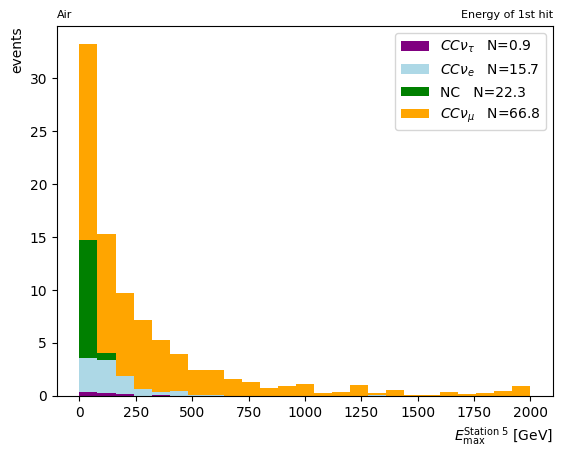

In [327]:
nc_data.hits_mask = compute_masks(nc_data.events, energy_threshold=10)
cc_el_data.hits_mask = compute_masks(cc_el_data.events, energy_threshold=10)
cc_mu_data.hits_mask = compute_masks(cc_mu_data.events, energy_threshold=10)
cc_tau_data.hits_mask = compute_masks(cc_tau_data.events, energy_threshold=10)


nc_energy_hist     = bh.Histogram(bh.axis.Regular(25, 0, 2000))
cc_el_energy_hist  = bh.Histogram(bh.axis.Regular(25, 0, 2000))
cc_mu_energy_hist  = bh.Histogram(bh.axis.Regular(25, 0, 2000))
cc_tau_energy_hist = bh.Histogram(bh.axis.Regular(25, 0, 2000))

nc_energy_hist = fill_hits_histogram(nc_energy_hist, nc_data, "E", func=max)
cc_el_energy_hist = fill_hits_histogram(cc_el_energy_hist, cc_el_data, "E", func=max)
cc_mu_energy_hist = fill_hits_histogram(cc_mu_energy_hist, cc_mu_data, "E", func=max)
cc_tau_energy_hist = fill_hits_histogram(cc_tau_energy_hist, cc_tau_data, "E", func=max)

plot_stacked_hist([nc_energy_hist, cc_el_energy_hist, cc_mu_energy_hist, cc_tau_energy_hist],
                  ["NC", r"$CC \nu_e$", r"$CC \nu_\mu$", r"$CC \nu_\tau$"],
                  ["green", "lightblue", "orange", "purple"],
                  scale_factor=air_sf, xlabel=r"$E_\text{max}^\text{Station 5}$ [GeV]", 
                  title_left="Air", title_right="Energy of 1st hit"
                  )

Neutral Current 303
Charged Current Electron 213
Charged Current Muon 918
Charged Current Tau 12
Total number of histogram entries: 106.3


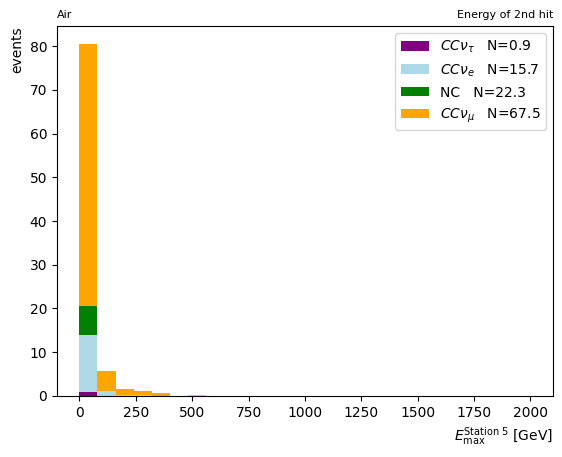

In [328]:

nc_energy_hist     = bh.Histogram(bh.axis.Regular(25, 0, 2000))
cc_el_energy_hist  = bh.Histogram(bh.axis.Regular(25, 0, 2000))
cc_mu_energy_hist  = bh.Histogram(bh.axis.Regular(25, 0, 2000))
cc_tau_energy_hist = bh.Histogram(bh.axis.Regular(25, 0, 2000))

nc_energy_hist = fill_hits_histogram(nc_energy_hist, nc_data, "E", func=min)
cc_el_energy_hist = fill_hits_histogram(cc_el_energy_hist, cc_el_data, "E", func=min)
cc_mu_energy_hist = fill_hits_histogram(cc_mu_energy_hist, cc_mu_data, "E", func=min)
cc_tau_energy_hist = fill_hits_histogram(cc_tau_energy_hist, cc_tau_data, "E", func=min)

plot_stacked_hist([nc_energy_hist, cc_el_energy_hist, cc_mu_energy_hist, cc_tau_energy_hist],
                  ["NC", r"$CC \nu_e$", r"$CC \nu_\mu$", r"$CC \nu_\tau$"],
                  ["green", "lightblue", "orange", "purple"],
                  scale_factor=air_sf, xlabel=r"$E_\text{max}^\text{Station 5}$ [GeV]", 
                  title_left="Air", title_right="Energy of 2nd hit"
                  )

Neutral Current 303
Charged Current Electron 213
Charged Current Muon 918
Charged Current Tau 12
Total number of histogram entries: 212.6


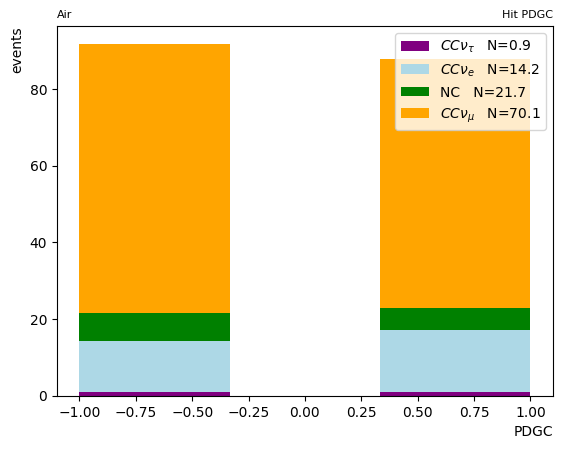

In [329]:
nc_data.hits_mask = compute_masks(nc_data.events, energy_threshold=10)
cc_el_data.hits_mask = compute_masks(cc_el_data.events, energy_threshold=10)
cc_mu_data.hits_mask = compute_masks(cc_mu_data.events, energy_threshold=10)
cc_tau_data.hits_mask = compute_masks(cc_tau_data.events, energy_threshold=10)


nc_energy_hist     = bh.Histogram(bh.axis.Regular(3, -1, 1))
cc_el_energy_hist  = bh.Histogram(bh.axis.Regular(3, -1, 1))
cc_mu_energy_hist  = bh.Histogram(bh.axis.Regular(3, -1, 1))
cc_tau_energy_hist = bh.Histogram(bh.axis.Regular(3, -1, 1))

nc_energy_hist = fill_hits_histogram(nc_energy_hist, nc_data, "charge")
cc_el_energy_hist = fill_hits_histogram(cc_el_energy_hist, cc_el_data, "charge")
cc_mu_energy_hist = fill_hits_histogram(cc_mu_energy_hist, cc_mu_data, "charge")
cc_tau_energy_hist = fill_hits_histogram(cc_tau_energy_hist, cc_tau_data, "charge")

plot_stacked_hist([nc_energy_hist, cc_el_energy_hist, cc_mu_energy_hist, cc_tau_energy_hist],
                  ["NC", r"$CC \nu_e$", r"$CC \nu_\mu$", r"$CC \nu_\tau$"],
                  ["green", "lightblue", "orange", "purple"],
                  scale_factor=air_sf, xlabel=r"PDGC", 
                    title_left="Air", title_right="Hit PDGC"
                  )

['mu+' 'pi-'] [ 1. -1.]
['pi+' 'pi+'] [1. 1.]
['anti-p~' 'p'] [-1.  1.]
['K+' 'pi-'] [ 1. -1.]
['pi+' 'pi-'] [ 1. -1.]
['K+' 'K-'] [ 1. -1.]
['pi+' 'pi-'] [ 1. -1.]
['pi+' 'pi-'] [ 1. -1.]
['pi-' 'pi-'] [-1. -1.]
['pi+' 'pi-'] [ 1. -1.]
['pi-' 'pi+'] [-1.  1.]
['K+' 'pi-'] [ 1. -1.]
['pi-' 'pi+'] [-1.  1.]
['pi+' 'K-'] [ 1. -1.]
['K+' 'pi-'] [ 1. -1.]
['pi-' 'pi+'] [-1.  1.]
['anti-p~' 'pi+'] [-1.  1.]
['pi+' 'pi+'] [1. 1.]
['pi+' 'pi-'] [ 1. -1.]
['p' 'anti-p~'] [ 1. -1.]
['pi-' 'pi+'] [-1.  1.]
['pi-' 'pi-'] [-1. -1.]
['p' 'pi-'] [ 1. -1.]
['K+' 'pi-'] [ 1. -1.]
['pi-' 'K+'] [-1.  1.]
['pi-' 'pi+'] [-1.  1.]
['pi-' 'pi+'] [-1.  1.]
['pi-' 'pi+'] [-1.  1.]
['pi-' 'pi+'] [-1.  1.]
['pi+' 'K-'] [ 1. -1.]
['pi-' 'pi-'] [-1. -1.]
['K+' 'K-'] [ 1. -1.]
['pi+' 'K-'] [ 1. -1.]
['pi-' 'pi+'] [-1.  1.]
['pi+' 'pi-'] [ 1. -1.]
['pi-' 'pi+'] [-1.  1.]
['pi-' 'pi+'] [-1.  1.]
['pi+' 'pi-'] [ 1. -1.]
['pi-' 'pi+'] [-1.  1.]
['K+' 'pi-'] [ 1. -1.]
['K-' 'pi+'] [-1.  1.]
['pi+' 'K-'] [ 1. -1.]
['pi+

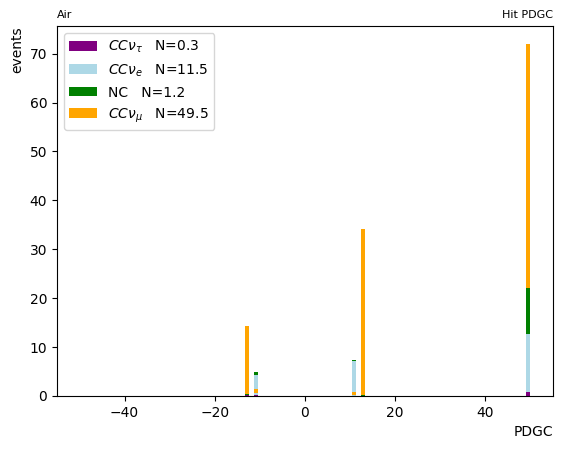

In [333]:
nc_data.hits_mask = compute_masks(nc_data.events, energy_threshold=10)
cc_el_data.hits_mask = compute_masks(cc_el_data.events, energy_threshold=10)
cc_mu_data.hits_mask = compute_masks(cc_mu_data.events, energy_threshold=10)
cc_tau_data.hits_mask = compute_masks(cc_tau_data.events, energy_threshold=10)


nc_energy_hist     = bh.Histogram(bh.axis.Regular(101, -50, 50))
cc_el_energy_hist  = bh.Histogram(bh.axis.Regular(101, -50, 50))
cc_mu_energy_hist  = bh.Histogram(bh.axis.Regular(101, -50, 50))
cc_tau_energy_hist = bh.Histogram(bh.axis.Regular(101, -50, 50))

nc_energy_hist = fill_hits_histogram(nc_energy_hist, nc_data, "pdgc")
cc_el_energy_hist = fill_hits_histogram(cc_el_energy_hist, cc_el_data, "pdgc")
cc_mu_energy_hist = fill_hits_histogram(cc_mu_energy_hist, cc_mu_data, "pdgc")
cc_tau_energy_hist = fill_hits_histogram(cc_tau_energy_hist, cc_tau_data, "pdgc")

plot_stacked_hist([nc_energy_hist, cc_el_energy_hist, cc_mu_energy_hist, cc_tau_energy_hist],
                  ["NC", r"$CC \nu_e$", r"$CC \nu_\mu$", r"$CC \nu_\tau$"],
                  ["green", "lightblue", "orange", "purple"],
                  scale_factor=air_sf, xlabel=r"PDGC", 
                    title_left="Air", title_right="Hit PDGC"
                  )